# Installation

In [1]:
# ✅ Toujours utiliser %pip dans Colab
%pip uninstall -y mmpose mmcv mmcv-lite mmdet >/dev/null 2>&1

# mmcv-lite en premier, PAS de C++ ops
%pip install -q mmcv-lite==2.0.1

# mmdet sans deps pour ne PAS tirer "mmcv" full
%pip install -q --no-deps mmdet==3.3.0

# Récupère le code MMPose v1.3.2 et PATCH pour éviter l'import des têtes "transformer"
import os, shutil, subprocess, textwrap, sys
repo = "/content/mmpose_cpu_patch"
shutil.rmtree(repo, ignore_errors=True)
subprocess.check_call(["git","clone","--depth","1","--branch","v1.3.2",
                       "https://github.com/open-mmlab/mmpose.git", repo])

# 1) Retirer 'chumpy' (inutile en 2D et problématique en Py3.12)
for meta in ("setup.cfg","pyproject.toml"):
    p = os.path.join(repo, meta)
    if os.path.exists(p):
        s = open(p,"r",encoding="utf-8").read().replace("chumpy","")
        open(p,"w",encoding="utf-8").write(s)

# 2) Désactiver totalement les "transformer_heads" (EDPose)
heads_init = os.path.join(repo, "mmpose/models/heads/__init__.py")
if os.path.exists(heads_init):
    s = open(heads_init,"r",encoding="utf-8").read()
    # supprime toute ligne qui importe transformer_heads
    s = "\n".join([ln for ln in s.splitlines() if "transformer_heads" not in ln])
    open(heads_init,"w",encoding="utf-8").write(s)

# 3) Supprime le dossier des transformer_heads pour être 100% safe
tf_dir = os.path.join(repo, "mmpose/models/heads/transformer_heads")
shutil.rmtree(tf_dir, ignore_errors=True)

# Installe le paquet patché (non-editable pour éviter les soucis de chemins)
%pip install -q /content/mmpose_cpu_patch

# Sanity checks
import importlib.util, pkgutil, mmcv, mmpose
print("mmcv version:", getattr(mmcv, "__version__", "N/A"))
print("mmcv._ext chargeable ?",
      end=" ")
try:
    import mmcv._ext as _ext
    print("Oui (peu probable en CPU).")
except Exception as e:
    print("Non (c'est attendu en CPU).")
print("mmpose file:", getattr(mmpose, "__file__", None))
print("mmpose.apis visible ?",
      importlib.util.find_spec("mmpose.apis") is not None)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 715.0/715.0 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
mmcv version: 2.0.1
mmcv._ext chargeable ? Non (c'est attendu en CPU).
mmpose file: /usr/local/lib/python3.12/dist-packages/mmpose/__init__.py
mmpose.apis visible ? True


# Nettoyage

In [2]:
from pathlib import Path

# 1) Supprime les imports/mentions d'EDPoseHead & transformer_heads dans heads/__init__.py
p_heads = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py')
txt = p_heads.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_heads.write_text(txt2, encoding='utf-8')

# 2) Supprime les mentions d'EDPoseHead & transformer_heads dans models/__init__.py
p_models = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py')
txt = p_models.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_models.write_text(txt2, encoding='utf-8')

print("Patched:", p_heads, "and", p_models)

# 3) Purge le cache d'import mmpose pour recharger les fichiers patchés
for k in list(sys.modules):
    if k.startswith('mmpose'):
        del sys.modules[k]
print("Import cache purged for mmpose.*")


Patched: /usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py and /usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py
Import cache purged for mmpose.*


# Téléchargement des poids du modèle (HRNetv2 avec dataset coco wholebody-hand)

In [3]:
import urllib.request

os.makedirs("/content/checkpoints", exist_ok=True)

# Checkpoint HRNetv2 (heatmap, compatible CPU)
ckpt = "/content/checkpoints/hrnetv2_w18_coco_256x256.pth"
if not os.path.exists(ckpt):
    urllib.request.urlretrieve(
        "https://download.openmmlab.com/mmpose/hand/hrnetv2/hrnetv2_w18_coco_wholebody_hand_256x256-1c028db7_20210908.pth",
        ckpt
    )

# Config (on prend celle de MMPose 1.3.2)
CFG = "/content/mmpose_cpu_patch/configs/hand_2d_keypoint/topdown_heatmap/coco_wholebody_hand/td-hm_hrnetv2-w18_8xb32-210e_coco-wholebody-hand-256x256.py"

print("Config et checkpoint prêts.")


Config et checkpoint prêts.


# Chargement du modèle

In [4]:
# charger le modèle en CPU
from mmpose.apis import init_model

model = init_model(CFG, ckpt, device="cpu")
print("Modèle chargé avec CFG =", CFG)

/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:33: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv`` rather than ``mmcv-lite`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '


Loads checkpoint by local backend from path: /content/checkpoints/hrnetv2_w18_coco_256x256.pth
Modèle chargé avec CFG = /content/mmpose_cpu_patch/configs/hand_2d_keypoint/topdown_heatmap/coco_wholebody_hand/td-hm_hrnetv2-w18_8xb32-210e_coco-wholebody-hand-256x256.py


/usr/local/lib/python3.12/dist-packages/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/coco_wholebody_hand.py" does not exist. A matched config file "/usr/local/lib/python3.12/dist-packages/mmpose/.mim/configs/_base_/datasets/coco_wholebody_hand.py" will be used instead.
  warnings.warn(


# Création des dossiers des données à traiter (Importer manuellement les images/vidéos)

In [5]:
os.makedirs('/content/images', exist_ok=True)
os.makedirs("/content/video", exist_ok=True)
!rm -rf /content/images/*
!rm -rf /content/video/*

# I. Main droite seule sur fond neutre

On s'intéresse pour l'instant à des images de mains vue de haut (dos de la main vers la caméra, doigts vers le haut de l'image, posture neutre au piano)

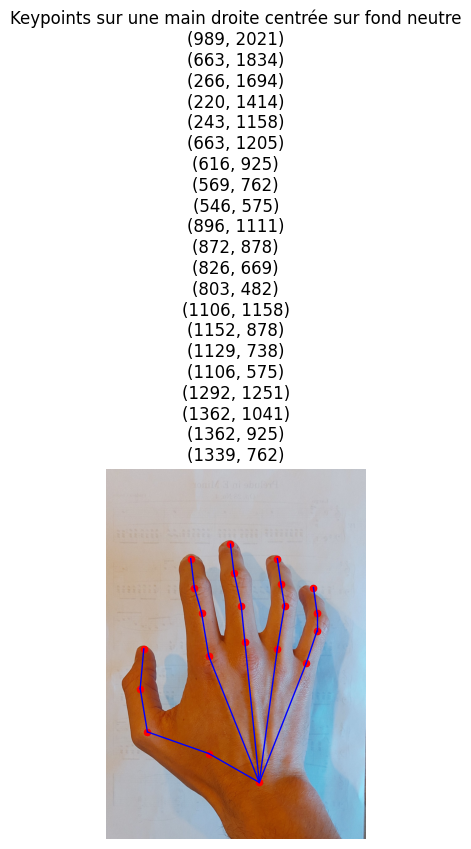

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from mmpose.apis import inference_topdown

HAND_SKELETON = [ # Pour le tracé du squelette reliant les keypoints
    (0, 1), (1, 2), (2, 3), (3, 4),       # pouce
    (0, 5), (5, 6), (6, 7), (7, 8),       # index
    (0, 9), (9,10), (10,11), (11,12),     # majeur
    (0,13), (13,14), (14,15), (15,16),    # annulaire
    (0,17), (17,18), (18,19), (19,20)     # auriculaire
]

def draw_hand_skeleton(hand_keypoints): # Fournir les coordonnées des keypoints associés à UNE main
    # Tracé des keypoints
    for (x, y) in hand_keypoints:
        plt.scatter(x, y, c='red', s=20)

    # Tracé du squelette
    for i, j in HAND_SKELETON:
        x_vals = [hand_keypoints[i, 0], hand_keypoints[j, 0]]
        y_vals = [hand_keypoints[i, 1], hand_keypoints[j, 1]]
        plt.plot(x_vals, y_vals, c='blue', linewidth=1)

img_path = '/content/images/main_fond_neutre.jpg' # à importer manuellement dans le notebook

im_pil = Image.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path, bboxes=[[0, 0, W, H]], bbox_format='xyxy')

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite centrée sur fond neutre\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

# II. Main droite seule sur piano

Le modèle n'a pas de difficulté particulière pour placer les keypoints sur une main dans des conditions idéales (la main est l'unique objet dans le cadre, fond neutre, luminosité acceptable...). Avant de passer à la vidéo, il convient de vérifier que notre modèle est capable de détecter correctement une main lorsque celle-ci est posée sur un piano.

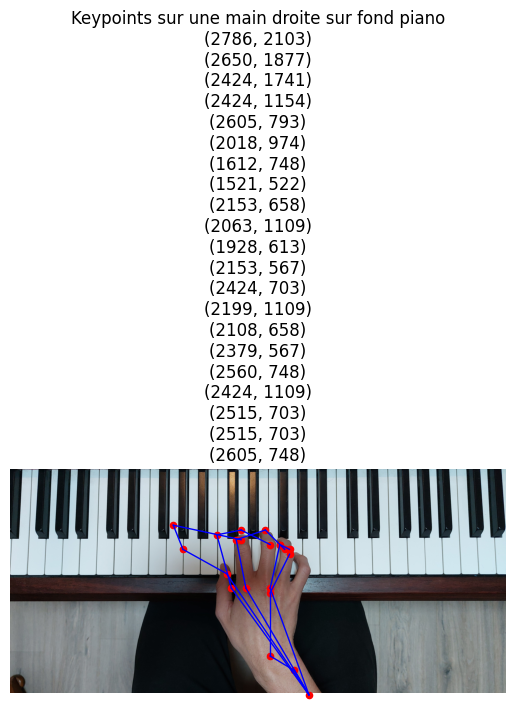

In [7]:
img_path = '/content/images/main_fond_piano.jpg' # à importer manuellement dans le notebook

im_pil = Image.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()


On observe que la main n'est pas bien détectée, essayons en rognant l'image pour conserver uniquement la partie autour de la main que l'on veut détecter.

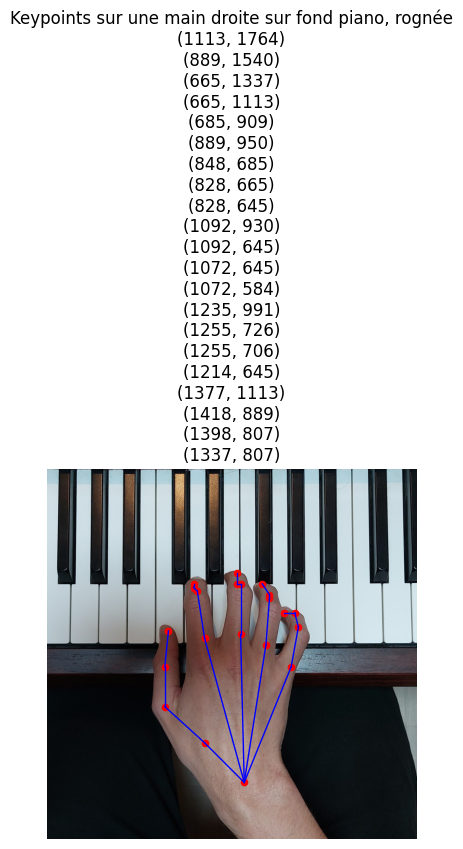

In [8]:
img_path = '/content/images/main_fond_piano_rognee.jpg' # à importer manuellement dans le notebook

im_pil = Image.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano, rognée\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

# TODO, adapter la suite

In [ ]:
import pandas as pd

df = pd.read_csv("out/keypoints.csv")
df = df.drop(columns = df.columns[df.columns.str.endswith('score')])
df.head()
nb_images = df.values.shape[0]
keypoints = [[] for _ in range(nb_images)]
for i in range(nb_images):
  values = df.iloc[i,2:].values
  for j in range(0, len(values),2):
    point = (values[j],values[j+1])
    keypoints[i].append(point)

keypoints_evolution = [[] for _ in range(len(keypoints[0]))]
for i in range(len(keypoints)):
  keypoint = []
  for j in range(len(keypoints[i])):
    keypoints_evolution[j].append(keypoints[i][j])
print(keypoints_evolution)

FileNotFoundError: [Errno 2] No such file or directory: 'out/keypoints.csv'

Calcul des trajectoires des Keypoints

In [ ]:
for i in range(len(kpts_names)):
  x, y = zip(*keypoints_evolution[i])
  plt.figure(figsize=(10, 6))

  img = cv2.imread(glob.glob('/content/images/*')[0])
  height, width = img.shape[:2]

  y = [height - y_i for y_i in y]

  plt.plot(x, y, label='Trajectoire')
  plt.plot(x[0], y[0], marker='o', markersize=10, color='green', label='Départ')
  plt.plot(x[-1], y[-1], marker='x', markersize=10, color='red', label='Arrivée')

  # --- Personnalisation ---
  plt.title(f'Trajectoire de {kpts_names[i]}')
  plt.xlabel('X')
  plt.ylabel('Y')

  plt.xlim(0, width)
  plt.ylim(0, height)
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.legend()

  plt.show()

In [ ]:
def merge_duplicates(points):
    l = [points[0]]
    for p in points[1:]:
        if p != l[-1]:
            l.append(p)
    return l

Calcul des vitesses

In [ ]:
delta = 1.0
for i in range(len(kpts_names)):
    points = keypoints_evolution[i]
    points = merge_duplicates(points)
    x, y = zip(*points)
    x = np.array(x)
    y = np.array(y)

    # np.diff : (x[i+1] - x[i])
    delta_x = np.diff(x)
    delta_y = np.diff(y)
    d = np.sqrt(delta_x**2 + delta_y**2)

    vitesse = d / delta
    t = np.arange(len(vitesse)) * delta

    plt.figure(figsize=(10, 6))
    plt.plot(t, vitesse, label='Vitesse')
    plt.scatter(t, vitesse, s=50)

    plt.title(f'Évolution de la Vitesse en fonction du Temps de {kpts_names[i]}')
    plt.xlabel('Temps t')
    plt.ylabel('Vitesse')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()